# AirBnB NYC Analytics Project 

* Project by Nhi Bui · Villanova University · [GitHub](https://github.com/nhibui23/airbnb-saas-product-analytics) · [LinkedIn](https://linkedin.com/in/nhiuyenbui)

## 07. Follow-up: Validating the Queens Finding

The original Python location analysis identified the Bronx 
as Airbnb's growth opportunity with high ratings and low supply. But when I 
extended the analysis in SQL using **demand-per-listing**, a different leader emerged: **Queens**.

* Purpose: Therefore, this notebook will close the loop by returning to Python to visualize the SQL finding and refine the original recommendation. The SQL analysis returned a 100+ row table of every Queens neighborhood, which now will be brought to Python for clear confirmation. 

**Key Findings**
- Which specific Queens neighborhoods need host-acquisition investment
- Whether "Entire home/apt wins in Queens" finding holds visually
- A shortlist of 5-10 neighborhoods for the team

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

df = pd.read_csv('../data/Airbnb_Open_Data_Cleaned.csv')
print(df.shape)

# Apply Airbnb branding guidelines
airbnb_coral = '#FF5A5F'  
airbnb_teal = '#00A699'   
airbnb_orange = '#FC642D' 
airbnb_dark = '#484848'   
airbnb_gray = '#767676'  

airbnb_palette = [airbnb_coral, airbnb_teal, airbnb_orange, airbnb_dark, airbnb_gray]

sns.set_palette(airbnb_palette)
sns.set_style('whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

(63718, 21)


### Heatmap: Rating by Neighborhood vs Room Type

In [2]:
queens = df[df['neighbourhood group'] == 'Queens'].copy()

In [3]:
# Build the neighborhood vs room type matrix
heatmap_data = queens.groupby(['neighbourhood', 'room type']).agg(avg_rating=('review rate number', 'mean'), listings=('id', 'count')).reset_index()

In [4]:
# Filter to minimum 20 listings
heatmap_data = heatmap_data[heatmap_data['listings'] >= 20]


In [5]:
# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(
    index='neighbourhood',
    columns='room type',
    values='avg_rating'
)


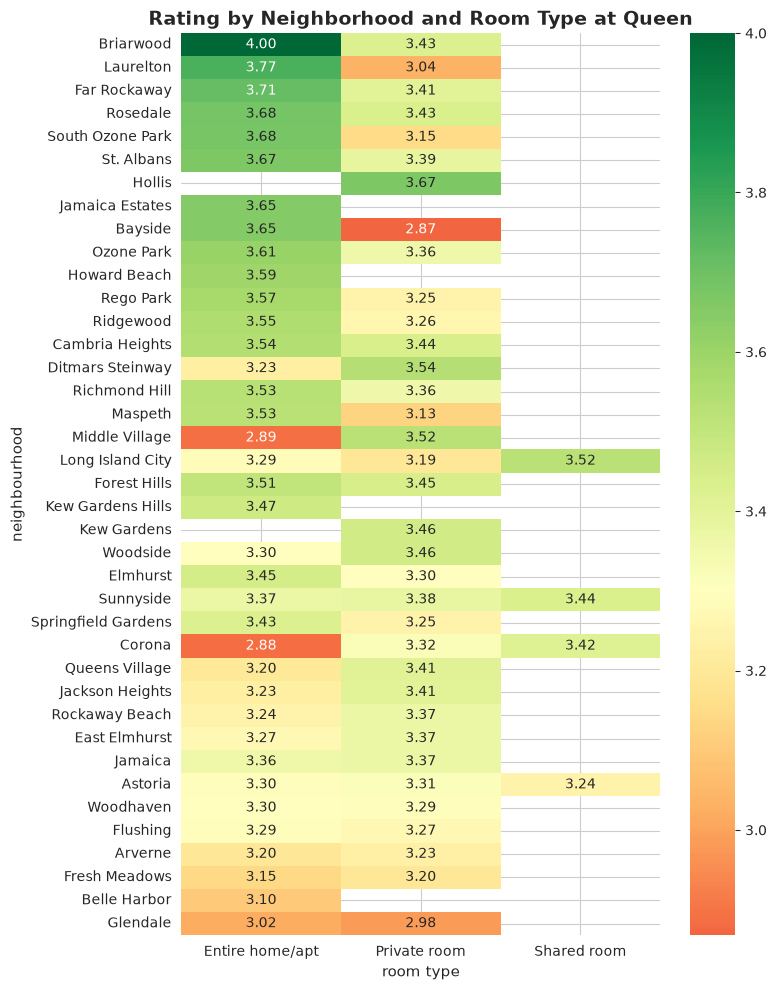

In [9]:
#Plot heatmap visualization

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=3.3)
plt.title('Rating by Neighborhood and Room Type at Queen')
plt.tight_layout()
plt.show()

In [10]:
# Keep only top 20 by max rating per row
heatmap_pivot = heatmap_pivot.loc[
    heatmap_pivot.max(axis=1).sort_values(ascending=False).head(20).index
]

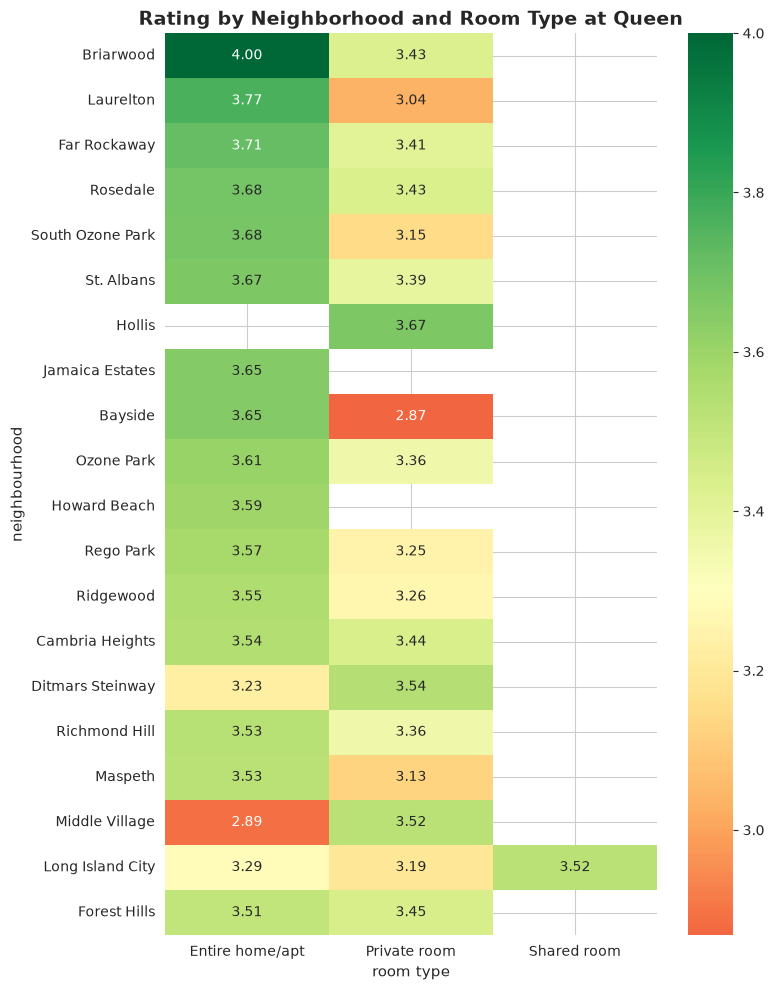

In [11]:
#Plot heatmap visualization again

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=3.3)
plt.title('Rating by Neighborhood and Room Type at Queen')
plt.tight_layout()
plt.show()